In [1]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [2]:
# Importing the TensorFlow library along with its layers for further uses

import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (Input, Reshape, Flatten, Dense, Dropout,
                                     BatchNormalization, RandomTranslation, RandomZoom)

(X_train, y_train), (X_test, y_test) = tensorflow.keras.datasets.fashion_mnist.load_data()

# scaling pixel values and normalizing

X_train = X_train / 255.0
X_test = X_test / 255.0




In [3]:
X_train.shape

(60000, 28, 28)

In [4]:
y_train

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

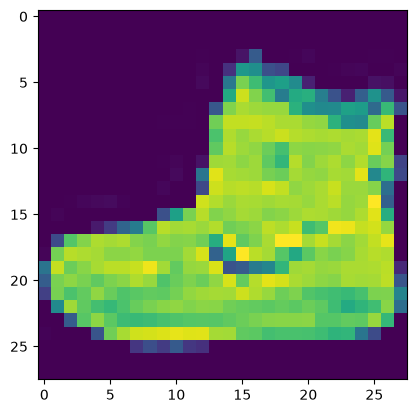

In [5]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])
# Shows ankle boot as it is mapped to the index 0

In [6]:
# Shows the normalized data stored in x train 
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [7]:
# Building a MLP model sequentially along with data augmentation 
model = Sequential([
    #input shape before grayscaling
    Input( shape=(28,28)),

    # Data augmentation is done to increase performance of the model
    Reshape ((28,28,1)),
    # 1 being the grayscale represents a single color channel needed for augmentation
    RandomTranslation(0.1,0.1),
    # shifts the digits randomly upto 10% of the image in each direction 
    RandomZoom(0.1),
    # Randomly zooms in or out by upto 10%

    Flatten(),
    # Flattens the image into 1D array of 28*28= 784 values

    # Layers are defined along with the parameters required 
    # Hidden layer 1
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Hidden layer2
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    #Hidden layer3
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    #hidden layer4
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    #hidden layer5
     Dense(128, activation='relu'),
     BatchNormalization(),
     Dropout(0.2),

    # Output layer
    Dense(10, activation='softmax'),

])


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 902,538 (3.44 MB)

 Trainable params: 899,210 (3.43 MB)

 Non-trainable params: 3,328 (13.00 KB)

In [9]:
# Compile the model by specifying the loss function, optimizer, and evaluation metrics
model.compile( loss= 'sparse_categorical_crossentropy',
               optimizer = keras.optimizers.Adam(learning_rate = 0.001),
               metrics = ['accuracy'])

# sparse_categorical_crossentropy is used due to the labels being an integer 
# Adam optimizer is being called with a learning rate of 0.001
# Accuracy is taken as a metric to measure the performance of the model during training and testing 

In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                                  restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                  patience=3, min_lr=1e-5),]

# callbacks can be inserted for analysis of the working of the model

# Train the model
# epochs=35        : an upper bound - EarlyStopping will usually stop around epoch 30
# batch_size=128   : how many images the model looks at before each weight update
# validation_split : hold back 08% of the training data to monitor performance
history = model.fit(X_train, y_train,
                    epochs=30,
                    batch_size=128,
                    validation_split=0.10,
                    callbacks = callbacks)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6945 - loss: 0.8229 - val_accuracy: 0.7967 - val_loss: 0.5535 - learning_rate: 0.0010
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7561 - loss: 0.6448 - val_accuracy: 0.8000 - val_loss: 0.5063 - learning_rate: 0.0010
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7706 - loss: 0.6088 - val_accuracy: 0.8055 - val_loss: 0.4937 - learning_rate: 0.0010
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7795 - loss: 0.5895 - val_accuracy: 0.7977 - val_loss: 0.5091 - learning_rate: 0.0010
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7846 - loss: 0.5739 - val_accuracy: 0.8078 - val_loss: 0.5399 - learning_rate: 0.0010
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7890 - loss: 0.5590 - val_accuracy: 0.8317 - val_loss: 0.4353 - learning_rate: 0.0010
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7975 - loss: 0

In [11]:
model.save('Fashion_classification_1.keras')

In [12]:
# Using the trained model to test data
y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [13]:
y_prob

array([[2.8786847e-06, 2.5214884e-05, 2.9161695e-06, ..., 2.1181377e-03,
        1.5497557e-06, 9.9442285e-01],
       [6.0246617e-04, 3.8786911e-06, 9.7599387e-01, ..., 5.7347238e-06,
        2.0002073e-05, 4.1232224e-06],
       [9.6859696e-07, 9.9999106e-01, 4.9680398e-07, ..., 2.0411107e-07,
        7.3373315e-07, 1.4150771e-07],
       ...,
       [9.2272807e-05, 6.5260733e-06, 2.3961069e-05, ..., 2.4841567e-05,
        9.9959463e-01, 1.4498494e-06],
       [1.7521053e-06, 9.9994910e-01, 1.2854853e-06, ..., 9.4742273e-07,
        8.8819735e-07, 7.5504005e-07],
       [4.8501926e-04, 7.7375997e-05, 3.1235234e-03, ..., 9.6302636e-02,
        1.0699206e-02, 1.2380673e-03]], shape=(10000, 10), dtype=float32)

In [14]:
y_pred = y_prob.argmax(axis=1)
# Taking the highest probability predicted by y_prob and storing it in y_pred making it an actual integer

In [15]:
y_pred

array([9, 2, 1, ..., 8, 1, 5], shape=(10000,))

In [16]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8672

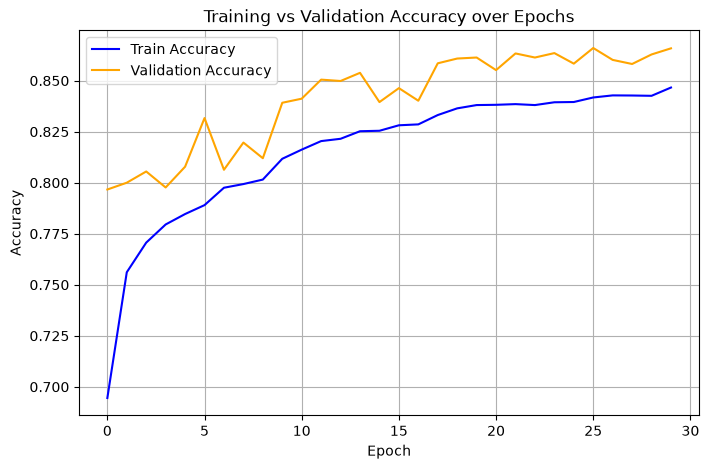

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training vs Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


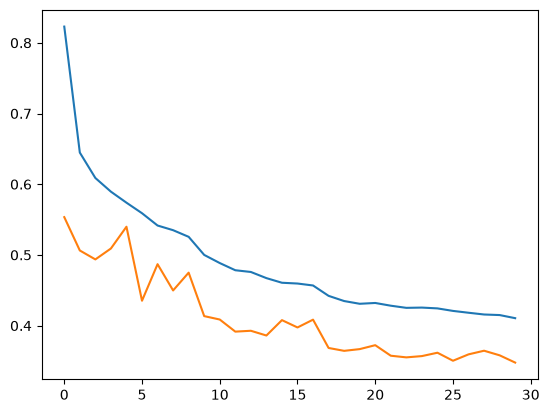

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

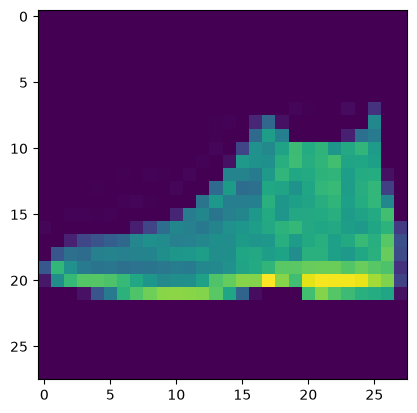

In [19]:
plt.imshow(X_test[0])



In [20]:
model.predict(X_test[1].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


array([2])

Image array shape: (28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


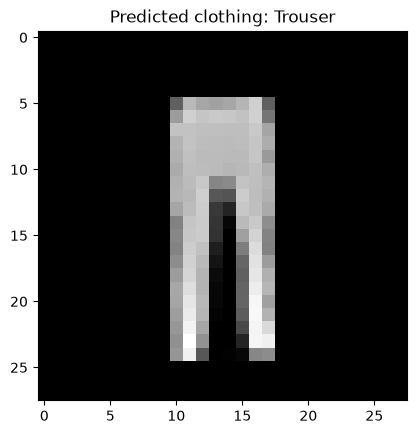

The predicted fashion wear is: Trouser


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from scipy import ndimage

# Load the model if it's not already loaded
model = keras.models.load_model('C:/Users/ACER/OneDrive/Desktop/AI ML notes/AI-GenAI-labs/Fashion_classification/Fashion_classification_1.keras')

# Load the image you want to test
img_path = 'C:/Users/ACER/OneDrive/Desktop/AI ML notes/AI-GenAI-labs/Fashion_classification/trouser.jpg'  # Replace with the path to your image file


def prepare_image(pil_image):
    """Turn a photo of any fashion wear into the 28x28 input the model expects.

    A phone photo looks nothing like MNIST, so there is real work to do here.
    """
    gray = pil_image.convert("L")
    a = np.asarray(gray, dtype=np.float32)
    big = max(gray.size)

    def ink(radius):
        """Whatever is DARKER than its own local background is ink.

        Blurring the photo estimates what the blank page looks like: the blur
        erases the pen strokes but keeps shadows and uneven lighting. Comparing
        against that also handles the inversion, since a photo is dark ink on
        white paper while MNIST is a white digit on black.
        """
        bg = np.asarray(gray.filter(ImageFilter.GaussianBlur(radius)), dtype=np.float32)
        return np.clip(bg - a, 0, None)

    # The blur radius has to be bigger than the pen stroke, or the "background"
    # eats into the stroke and hollows it out. But too big and it stops tracking
    # a sharp shadow edge. So measure the stroke first, then size the radius to it.
    rough = ink(big / 12.0)
    if rough.max() == 0:
        return np.zeros((28, 28), np.float32)
    rough_mask = rough > 0.4 * rough.max()
    if not rough_mask.any():
        return np.zeros((28, 28), np.float32)
    stroke = 2.0 * np.percentile(ndimage.distance_transform_edt(rough_mask)[rough_mask], 90)
    a = ink(float(np.clip(3.0 * stroke, big / 60.0, big / 3.0)))

    if a.max() == 0:
        return np.zeros((28, 28), np.float32)

    # Keep only the biggest connected blob of ink. That is the data - ruled
    # paper lines, smudges and dust specks get dropped here.
    mask = a > 0.35 * a.max()
    labels, n = ndimage.label(mask)
    if n > 1:
        sizes = ndimage.sum(mask, labels, range(1, n + 1))
        mask = labels == (1 + int(np.argmax(sizes)))
    if not mask.any():
        return np.zeros((28, 28), np.float32)

    # Crop tight to the item, then rebuild the MNIST framing ourselves: scale the
    # longest side to 20px and paste it centred into a 28x28 box. Taking the margin
    # from the photo instead would fail whenever someone zooms right in.
    ys, xs = np.where(mask)
    a = a[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
    a = a / a.max() * 255.0

    h, w = a.shape
    scale = 20.0 / max(h, w)
    nh, nw = max(1, int(round(h * scale))), max(1, int(round(w * scale)))
    small = np.asarray(Image.fromarray(a.astype(np.uint8)).resize((nw, nh), Image.LANCZOS),
                       dtype=np.float32)

    out = np.zeros((28, 28), np.float32)
    top, left = (28 - nh) // 2, (28 - nw) // 2
    out[top:top + nh, left:left + nw] = small

    # MNIST digits sit at their centre of mass, not the centre of their box.
    total = out.sum()
    if total > 0:
        idx = np.arange(28)
        dy = int(round(13.5 - out.sum(1) @ idx / total))
        dx = int(round(13.5 - out.sum(0) @ idx / total))
        shifted = np.zeros_like(out)
        y0, y1 = max(0, dy), 28 + min(0, dy)
        x0, x1 = max(0, dx), 28 + min(0, dx)
        shifted[y0:y1, x0:x1] = out[y0 - dy:y1 - dy, x0 - dx:x1 - dx]
        out = shifted

    return out / max(out.max(), 1e-6)


img_array = prepare_image(Image.open(img_path))
print("Image array shape:", img_array.shape)

# Predict the digit
y_prob = model.predict(img_array.reshape(1, 28, 28))  # Get the prediction probabilities
y_pred = y_prob.argmax(axis=1)  # Get the predicted class label

# Show the image the way the MODEL sees it, not the way the file looks.
# it. If it is not, the prediction will be wrong - fix the photo, not the model.
plt.imshow(img_array, cmap='gray')
plt.title(f'Predicted clothing: {class_names[y_pred[0]]}')
plt.show()

# Print the predicted wear
print(f'The predicted fashion wear is: {class_names[y_pred[0]]}')
